# 03 · Appearance of the structural backfire effect  (Paper Fig 1)

Three-group log-response time series for the canonical cell (HK $p_t{=}0.3$, $\mu{=}0.8$, $\epsilon_s{=}0.5$, exp `63f67d05`). Saves `results/summary/backfire_3group_logresp_A2.png`.

In [1]:
# --- bootstrap: run from anywhere; cd to repo root (has results/ and src/) ---
import os
for _ in range(5):
    if os.path.isdir('results') and os.path.isdir('src'):
        break
    os.chdir('..')
print('working dir:', os.getcwd())

working dir: /home/tomoyatakeda/document/research/manipulation-backfire-model


# Sec 4.3 — Appearance of the Backfire Effect (3-group log-response)

Time series of the per-group **log-response** for the baseline condition
**HK($p_t$=0.3), $\mu$=0.8, $\epsilon_s$=0.5** (exp_id `63f67d05`).

Keeps the original Sec 4.3 three-line form, but each opinion group is
normalized to its OWN fixed PRE baseline mean over `[19000, 20000]` so the
manipulation-induced change is the signal rather than the static share offset:

$$\text{logresp}_g(t)=\log\!\big[\,v_g(t)\,/\,v_g^{\text{pre}}\,\big]$$

Groups are oriented by the manipulation direction:
`target = near_target + far_target`, `neutral`, `opposite = far_opposite + near_opposite`.
By construction `opposite_line - target_line = b(t)`, the time-resolved
analogue of the scalar backfire metric `b` used in Sec 4.4.

**Trial set (A2):** first 30 seeds, BOTH manipulation directions ($\pm 1$) pooled.
Each trial = (seed, target_sign); per-trial log-response is averaged across
trials with a standard-error band. The PRE-baseline drop rule of Sec 4.4
(`PRE_MIN_THRESHOLD`) is mirrored for consistency.

In [2]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Configuration -----------------------------------------------------------
EXP_DIR = os.path.join(
    "results", "summary", "HolmeKim", "A_1_m_3_pt_0.3", "63f67d05"
)
POST_CSV = os.path.join(EXP_DIR, "post_count_100step.csv")
SEEDS_JSON = os.path.join(EXP_DIR, "selected_seeds.json")
OUT_PNG = os.path.join("results", "summary", "backfire_3group_logresp_A2.png")

MANIP_STEP = 20000           # manipulation onset
PRE_RANGE = (19000, 20000)   # fixed PRE baseline window (== Sec 4.4)
PRE_MIN_THRESHOLD = 1.0      # drop trials with near-empty pre-baseline group
N_FIRST_SEEDS = 30           # A2 = first 30 seeds

# Visualization-only smoothing of the per-trial volume series before logs.
# Centered rolling mean over SMOOTH_BINS 100-step bins; PRE baseline (a window
# mean) is unaffected. Set to 1 to disable.
SMOOTH_BINS = 10             # 10 bins = 1000 steps

OPP_COLS = ["far_opposite", "near_opposite"]
TGT_COLS = ["near_target", "far_target"]
GROUPS_3 = {
    "target":   (TGT_COLS,    "#d62728"),  # manipulated side
    "neutral":  (["neutral"], "#7f7f7f"),
    "opposite": (OPP_COLS,    "#1f77b4"),  # opposing side
}

In [3]:
def trial_group_logresp(grp):
    """Return (steps, {group: logresp_t}) for one trial, or None if dropped."""
    grp = grp.sort_values("step")
    steps = grp["step"].to_numpy()
    pre_mask = (steps >= PRE_RANGE[0]) & (steps <= PRE_RANGE[1])
    if pre_mask.sum() == 0:
        return None

    raw = {g: grp[cols].sum(axis=1).to_numpy(dtype=float)
           for g, (cols, _) in GROUPS_3.items()}
    pre = {g: v[pre_mask].mean() for g, v in raw.items()}

    # Same exclusion as Sec 4.4: unstable log when target/opposite pre ~empty.
    if pre["target"] < PRE_MIN_THRESHOLD or pre["opposite"] < PRE_MIN_THRESHOLD:
        return None

    eps = 1e-9
    out = {}
    for g, v in raw.items():
        if SMOOTH_BINS > 1:
            v = pd.Series(v).rolling(SMOOTH_BINS, center=True,
                                     min_periods=1).mean().to_numpy()
        out[g] = np.log((v + eps) / pre[g])
    return steps, out


def aggregate_group_logresp(df_post):
    """Average per-trial log-response across trials. Returns (steps, {g:(mean,se)}, n)."""
    ref_steps = None
    stacks = {g: [] for g in GROUPS_3}
    n = 0
    for _, grp in df_post.groupby(["seed", "target_sign"]):
        res = trial_group_logresp(grp)
        if res is None:
            continue
        steps, out = res
        if ref_steps is None:
            ref_steps = steps
        for g, series in out.items():
            if len(series) != len(ref_steps):
                series = np.interp(ref_steps, steps, series)
            stacks[g].append(series)
        n += 1
    if n == 0:
        return None
    result = {}
    for g, lst in stacks.items():
        arr = np.vstack(lst)
        mean = arr.mean(axis=0)
        se = arr.std(axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(mean)
        result[g] = (mean, se)
    return ref_steps, result, n

In [4]:
# --- Build the A2 trial set: first 30 seeds, both directions -----------------
df_post = pd.read_csv(POST_CSV)
with open(SEEDS_JSON) as f:
    selected = json.load(f)["selected"]
first_seeds = set(selected[:N_FIRST_SEEDS])

d = df_post[df_post["seed"].isin(first_seeds)]  # both target_sign kept
agg = aggregate_group_logresp(d)
assert agg is not None, "no valid trials"
steps, res, n = agg
print(f"A2 trials used (seed x direction): n = {n}")

A2 trials used (seed x direction): n = 60


Saved: results/summary/backfire_3group_logresp_A2.png


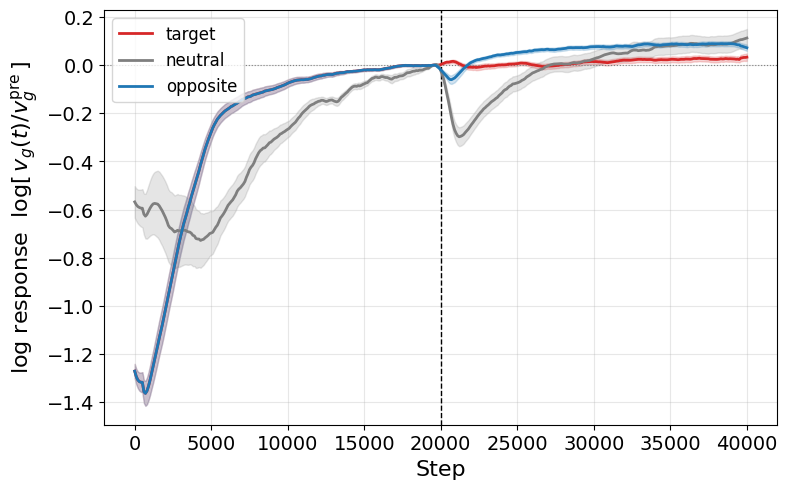

In [5]:
# --- Plot: 3-group log-response time series (no inset) ------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0.0, color="grey", lw=0.8, ls=":")
ax.axvline(MANIP_STEP, color="black", lw=1.0, ls="--")
for g, (_, color) in GROUPS_3.items():
    mean, se = res[g]
    ax.plot(steps, mean, color=color, lw=2.0, label=g)
    ax.fill_between(steps, mean - se, mean + se, color=color, alpha=0.2)

ax.tick_params(axis="both", labelsize=14)
ax.set_xlabel("Step", fontsize=16)
ax.set_ylabel(r"log response  $\log[\,v_g(t)/v_g^{\mathrm{pre}}\,]$", fontsize=16)
# ax.set_title(
#     "Appearance of the backfire effect (Sec 4.3)\n"
#     r"HK($p_t$=0.3), $\mu$=0.8, $\epsilon_s$=0.5 | first 30 seeds, both directions"
#     f"  (n={n})"
# )
ax.legend(loc="upper left", fontsize=12)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=150)
print(f"Saved: {OUT_PNG}")
plt.show()